In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Test paths and display labels
TESTS = {
    'test_1': 'Test 1',
    'test_2': 'Test 2',
    'test_3': 'Test 3',
}

DATASETS = ['ArtDL', 'ICONCLASS', 'wikidata']

# Model families: each maps model folder name -> display label
MODEL_FAMILIES = {
    'Gemini Flash Lite': {
        'gemini-2.5-flash-lite':         'Gemini 2.5 Flash Lite\n(2025)',
        'gemini-3.1-flash-lite-preview':  'Gemini 3.1 Flash Lite\n(2026)',
    },
    'Gemini Flash': {
        'gemini-2.5-flash':       'Gemini 2.5 Flash\n(2025)',
        'gemini-3-flash-preview': 'Gemini 3 Flash\n(2026)',
    },
    'Gemini Pro': {
        'gemini-2.5-pro':         'Gemini 2.5 Pro\n(2025)',
        'gemini-3.1-pro-preview': 'Gemini 3.1 Pro\n(2026)',
    },
    'GPT Mini': {
        'gpt-4o-mini-2024-07-18': 'GPT-4o mini\n(2024)',
        'gpt-5-mini-2025-08-07':  'GPT-5 mini\n(2025)',
    },
    'GPT Full': {
        'gpt-4o-2024-11-20':   'GPT-4o\n(2024)',
        'gpt-5.2-2025-12-11':  'GPT-5.2\n(2025)',
    },
}

# Elegant, muted color palette (Tableau-inspired)
TEST_COLORS = {
    'test_1': '#4e79a7',  # steel blue
    'test_2': '#e15759',  # muted red
    'test_3': '#59a14f',  # sage green
}


def load_accuracy(test_path, dataset, model_name):
    """Return accuracy as a float (0-1) or None if not available."""
    csv = os.path.join(test_path, dataset, model_name, 'summary_metrics.csv')
    if not os.path.exists(csv):
        return None
    df = pd.read_csv(csv)
    rows = df.loc[df['Model'] == model_name, 'Accuracy']
    if rows.empty:
        return None
    val = rows.values[0]
    if isinstance(val, str):
        return float(val.rstrip('%')) / 100.0
    return float(val)


def collect_data():
    """
    Returns a nested dict:
        data[dataset][family_name][test_key] = list of (x_label, accuracy) pairs
    """
    data = {}
    for dataset in DATASETS:
        data[dataset] = {}
        for family_name, models in MODEL_FAMILIES.items():
            data[dataset][family_name] = {}
            for test_key in TESTS:
                points = []
                for model_id, x_label in models.items():
                    acc = load_accuracy(test_key, dataset, model_id)
                    points.append((x_label, acc))
                data[dataset][family_name][test_key] = points
    return data


data = collect_data()
print('Data loaded.')


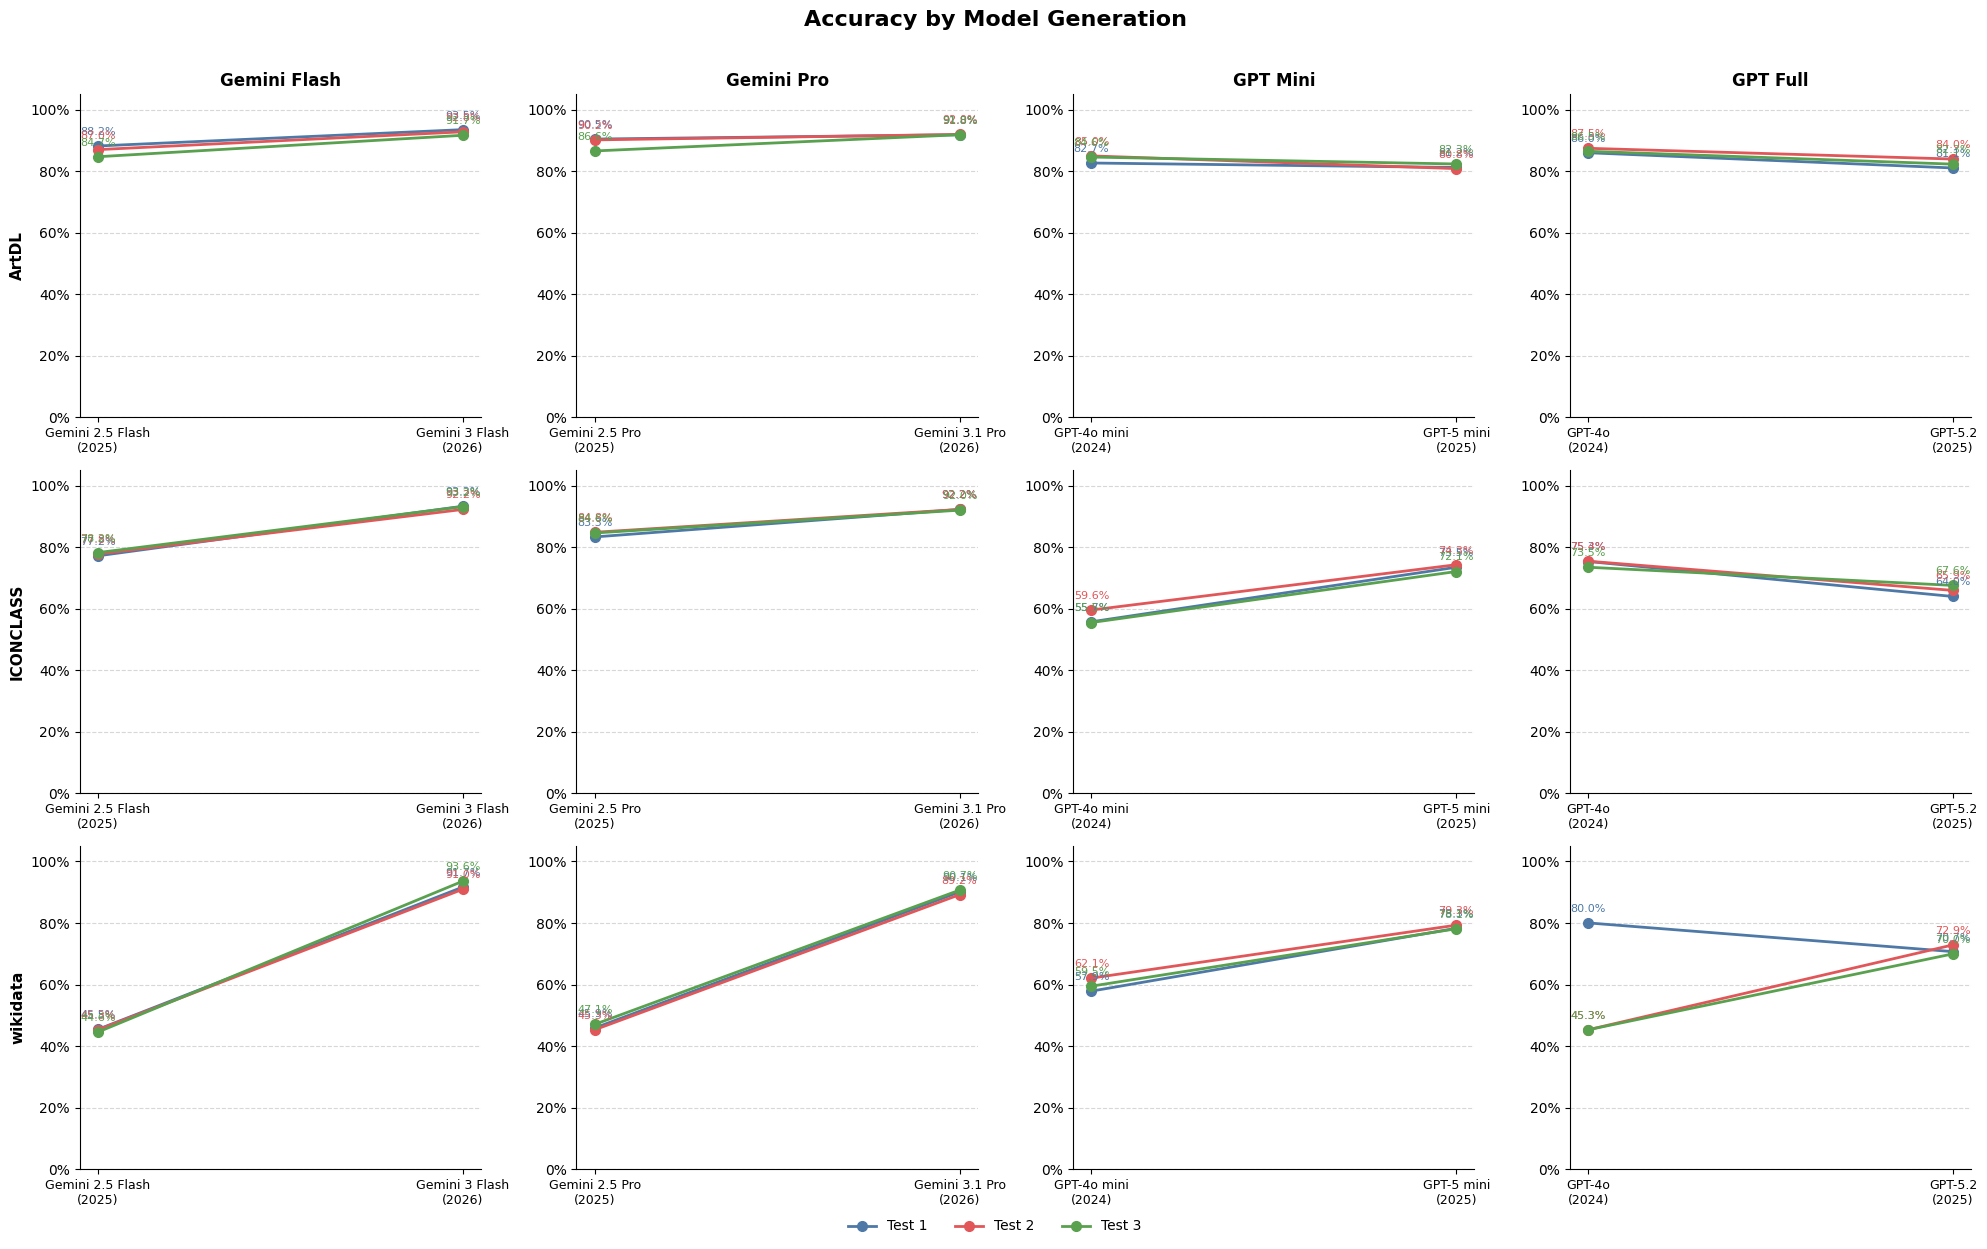

Saved to generation_compare.png


In [2]:
# Generation comparison: line plots
# Layout: rows = datasets, columns = model families

n_rows = len(DATASETS)
n_cols = len(MODEL_FAMILIES)
family_names = list(MODEL_FAMILIES.keys())

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=False,
)
fig.suptitle('Accuracy by Model Generation', fontsize=16, fontweight='bold', y=1.01)

for row_idx, dataset in enumerate(DATASETS):
    for col_idx, family_name in enumerate(family_names):
        ax = axes[row_idx][col_idx]
        family_data = data[dataset][family_name]

        x_labels = [pt[0] for pt in next(iter(family_data.values()))]
        x_pos = list(range(len(x_labels)))

        for test_key, test_label in TESTS.items():
            points = family_data[test_key]
            y_vals = [pt[1] for pt in points]

            # Draw only where data exists
            valid_x = [x_pos[i] for i, v in enumerate(y_vals) if v is not None]
            valid_y = [v for v in y_vals if v is not None]

            if valid_x:
                ax.plot(
                    valid_x, valid_y,
                    marker='o', linewidth=2, markersize=7,
                    color=TEST_COLORS[test_key],
                    label=test_label,
                )
                # Annotate each point with its value
                for xi, yi in zip(valid_x, valid_y):
                    ax.annotate(
                        f'{yi:.1%}',
                        (xi, yi),
                        textcoords='offset points',
                        xytext=(0, 8),
                        ha='center',
                        fontsize=8,
                        color=TEST_COLORS[test_key],
                    )

        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, fontsize=9)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.spines[['top', 'right']].set_visible(False)

        # Titles
        if row_idx == 0:
            ax.set_title(family_name, fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(dataset, fontsize=11, fontweight='bold')

# Single shared legend below the figure
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=len(TESTS),
    fontsize=10,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
)

plt.tight_layout()
plt.savefig('generation_compare.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to generation_compare.png')

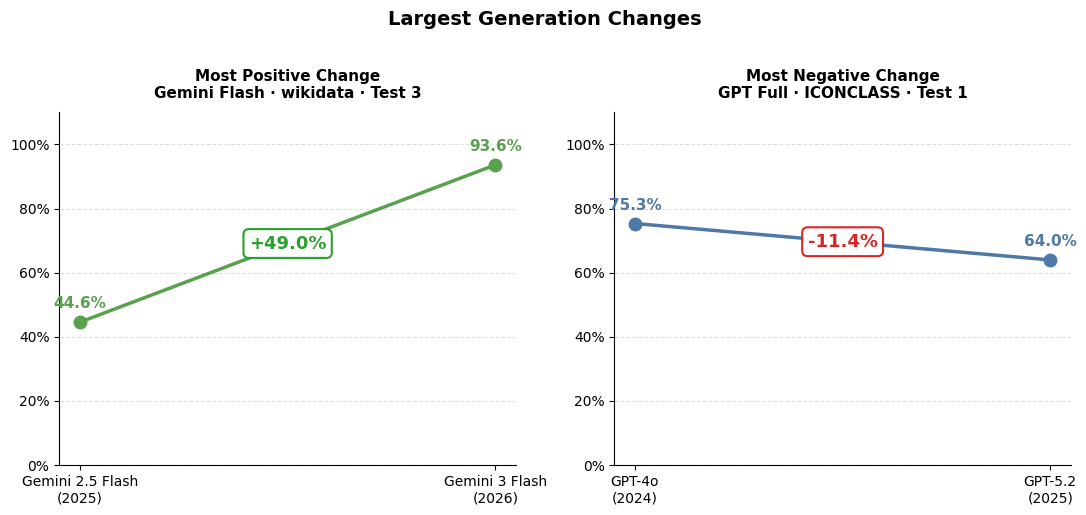

Best:  Gemini Flash / wikidata / Test 3  Δ=+49.0%
Worst: GPT Full / ICONCLASS / Test 1  Δ=-11.4%


In [3]:
# Best and worst generation change
# Find the (dataset, family, test) combination with the largest and smallest delta

def compute_deltas():
    """
    For each (dataset, family_name, test_key), compute delta = new_acc - old_acc.
    Returns list of dicts with keys: dataset, family, test_key, old_label, new_label,
                                     old_acc, new_acc, delta
    """
    records = []
    for dataset in DATASETS:
        for family_name, models in MODEL_FAMILIES.items():
            model_ids = list(models.keys())
            model_labels = list(models.values())
            for test_key in TESTS:
                old_acc = load_accuracy(test_key, dataset, model_ids[0])
                new_acc = load_accuracy(test_key, dataset, model_ids[1])
                if old_acc is not None and new_acc is not None:
                    records.append({
                        'dataset': dataset,
                        'family': family_name,
                        'test_key': test_key,
                        'old_label': model_labels[0],
                        'new_label': model_labels[1],
                        'old_acc': old_acc,
                        'new_acc': new_acc,
                        'delta': new_acc - old_acc,
                    })
    return records


def draw_change_panel(ax, record, title_prefix):
    """Draw a two-point line plot for a single best/worst combination."""
    color = TEST_COLORS[record['test_key']]
    x_pos = [0, 1]
    x_labels = [record['old_label'], record['new_label']]
    y_vals = [record['old_acc'], record['new_acc']]

    ax.plot(x_pos, y_vals, marker='o', linewidth=2.5, markersize=9, color=color)

    # Annotate each point
    for xi, yi in zip(x_pos, y_vals):
        ax.annotate(
            f'{yi:.1%}', (xi, yi),
            textcoords='offset points', xytext=(0, 10),
            ha='center', fontsize=11, fontweight='bold', color=color,
        )

    # Delta badge in the middle
    delta = record['delta']
    sign = '+' if delta >= 0 else ''
    badge_color = '#2ca02c' if delta >= 0 else '#d62728'
    ax.annotate(
        f'{sign}{delta:.1%}',
        xy=(0.5, (y_vals[0] + y_vals[1]) / 2),
        xytext=(0, 0),
        textcoords='offset points',
        ha='center', va='center',
        fontsize=13, fontweight='bold', color=badge_color,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=badge_color, linewidth=1.5),
    )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

    subtitle = f"{record['family']} · {record['dataset']} · {TESTS[record['test_key']]}"
    ax.set_title(
        f"{title_prefix}\n{subtitle}",
        fontsize=11, fontweight='bold', pad=10,
    )


deltas = compute_deltas()
best = max(deltas, key=lambda r: r['delta'])
worst = min(deltas, key=lambda r: r['delta'])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('Largest Generation Changes', fontsize=14, fontweight='bold', y=1.02)

draw_change_panel(axes[0], best,  'Most Positive Change')
draw_change_panel(axes[1], worst, 'Most Negative Change')

plt.tight_layout()
plt.savefig('generation_extremes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best:  {best['family']} / {best['dataset']} / {TESTS[best['test_key']]}  Δ={best['delta']:+.1%}")
print(f"Worst: {worst['family']} / {worst['dataset']} / {TESTS[worst['test_key']]}  Δ={worst['delta']:+.1%}")
